# 🧠 Credit Card Customer Churn Prediction

## 📌 Project Overview

Customer churn is a major challenge for financial institutions. Retaining existing customers is often more cost-effective than acquiring new ones.

This project builds a **machine learning model to predict whether a customer will leave the bank (churn)** based on demographic and financial attributes.

The final model is deployed using a **Streamlit dashboard** that allows users to input customer details and receive churn predictions in real time.

## 📂 Dataset Description

The dataset used in this project is the **Credit Card Customer Churn dataset from Kaggle**.

- **Total Records:** 10,000 customers  
- **Features:** 14 columns (`RowNumber`, `CustomerId`, `Surname` dropped before modelling)
- **Target Variable:** `Exited` (1 = Churned, 0 = Stayed)
- **Class Distribution:** 79.6% Stayed / 20.4% Churned (imbalanced — handled via class weights)

### 🔑 Key Features

| Feature | Description |
|------|------|
| CreditScore | Customer credit score |
| Geography | Customer location (France, Germany, Spain) — one-hot encoded |
| Gender | Male / Female — one-hot encoded |
| Age | Customer age |
| Tenure | Years with bank |
| Balance | Account balance |
| NumOfProducts | Number of bank products |
| HasCrCard | Has credit card (1 = Yes, 0 = No) |
| IsActiveMember | Active member status (1 = Yes, 0 = No) |
| EstimatedSalary | Customer estimated salary |

In [1]:
!pip install tensorflow scikit-learn pandas numpy matplotlib seaborn joblib

In [2]:
# ── All imports ──────────────────────────────────────────────────────────────
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

print(f"TensorFlow version: {tf.__version__}")


TensorFlow version: 2.15.0


In [3]:
import os

# Always resolve relative to the notebook's location
notebook_dir = os.path.dirname(os.path.abspath("churn_analysis.ipynb"))
project_root = os.path.dirname(notebook_dir)  # go up one level from notebooks/

df = pd.read_csv(os.path.join(project_root, "data", "raw", "Churn_Modelling.csv"))
print("Data loaded successfully!")
print(f"Shape: {df.shape}")

Data loaded successfully!
Shape: (10000, 14)


In [ ]:
# ── Loading data ───────────────────────────────────────────────────────────
df = pd.read_csv("../data/raw/Churn_Modelling.csv")

print("Data loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Data loaded successfully!
Shape: (10000, 14)
Columns: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


## 📊 Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps understand the dataset and identify patterns that may influence customer churn.  
In this section, we analyze how different factors such as customer demographics and account information relate to churn behavior.

> **Note:** EDA is performed on the raw dataframe before any preprocessing. All transformations (dropping columns, encoding) happen later in the Preprocessing section.

---

### 📉 Churn Distribution

This visualization shows the distribution of customers who **left the bank (churned)** versus those who **remained**.

---

### 🌍 Geographic Impact on Churn

This analysis explores how **customer location (Geography)** affects churn behavior.

---

### 👥 Age-Based Churn Patterns

Customer age can play an important role in predicting churn.

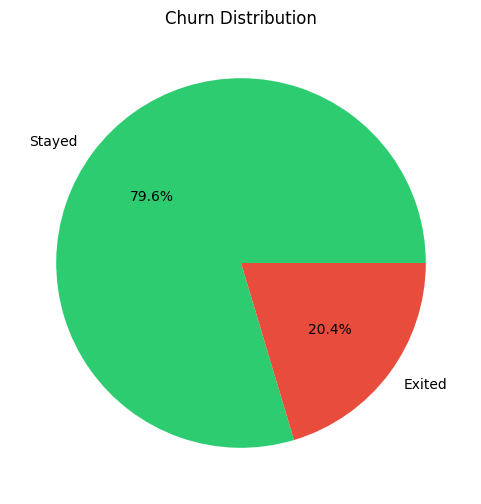

Stayed : 7,963 (79.6%)
Churned: 2,037 (20.4%)


In [5]:
# ── EDA Plot 1: Churn distribution ───────────────────────────────────────────
# EDA uses the raw df without any modifications
churn_counts = df['Exited'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(churn_counts, labels=['Stayed', 'Exited'], autopct='%1.1f%%',
        colors=['#2ecc71', '#e74c3c'])
plt.title('Churn Distribution')
plt.show()

print(f"Stayed : {churn_counts[0]:,} ({churn_counts[0]/len(df)*100:.1f}%)")
print(f"Churned: {churn_counts[1]:,} ({churn_counts[1]/len(df)*100:.1f}%)")

The dataset shows an imbalanced class distribution:
- **79.6%** of customers stayed with the bank
- **20.4%** of customers churned (left the bank)

This imbalance (approximately 80/20) is typical for churn prediction problems and is addressed during model training using **class weights**.

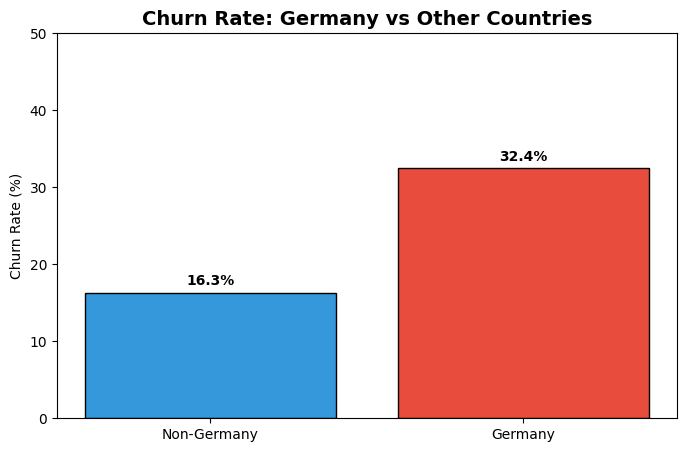

Germany churn rate    : 32.4%
Non-Germany churn rate: 16.3%


In [6]:
# ── EDA Plot 2: Geography vs churn ──────────────────────────────────────────
# Work on a temporary copy so the raw df stays untouched
df_geo = df.copy()
df_geo = pd.get_dummies(df_geo, columns=['Geography'], drop_first=False)

germany_churn     = df_geo[df_geo['Geography_Germany'] == 1]['Exited'].mean() * 100
non_germany_churn = df_geo[df_geo['Geography_Germany'] == 0]['Exited'].mean() * 100

plt.figure(figsize=(8, 5))
categories  = ['Non-Germany', 'Germany']
churn_rates = [non_germany_churn, germany_churn]
colors      = ['#3498db', '#e74c3c']

bars = plt.bar(categories, churn_rates, color=colors, edgecolor='black')
plt.title('Churn Rate: Germany vs Other Countries', fontsize=14, fontweight='bold')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 50)

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., h + 1,
             f'{h:.1f}%', ha='center', fontweight='bold')
plt.show()

print(f"Germany churn rate    : {germany_churn:.1f}%")
print(f"Non-Germany churn rate: {non_germany_churn:.1f}%")

<30: 7.5% churn rate (1968 customers)
30-40: 12.1% churn rate (4451 customers)
40-50: 34.0% churn rate (2320 customers)
50-60: 56.2% churn rate (797 customers)
60+: 24.8% churn rate (464 customers)


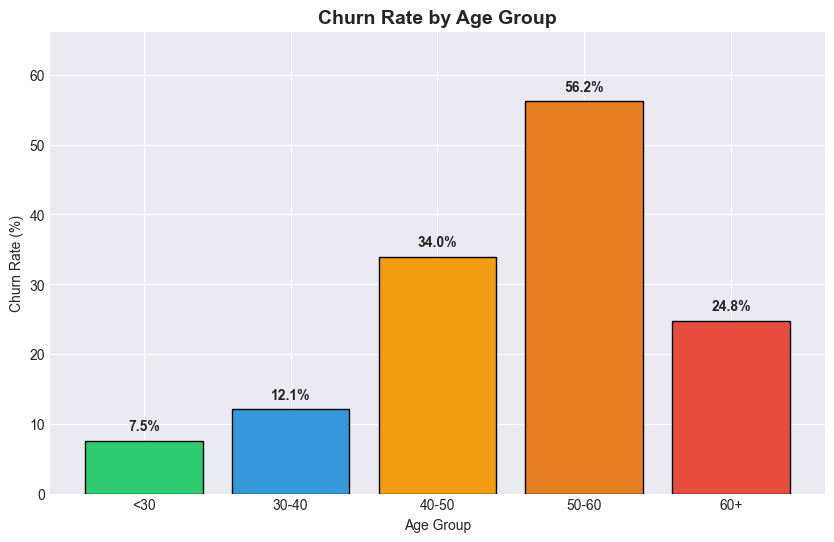

In [19]:
# ── EDA Plot 3: Age group vs churn ──────────────────────────────────────────
df_age = df.copy()
df_age['Age_group'] = pd.cut(
    df_age['Age'],
    bins=[0, 30, 40, 50, 60, 100],
    labels=['<30', '30-40', '40-50', '50-60', '60+']
)

age_groups      = ['<30', '30-40', '40-50', '50-60', '60+']
age_churn_rates = []

for ag in age_groups:
    grp        = df_age[df_age['Age_group'] == ag]
    rate       = grp['Exited'].mean() * 100
    age_churn_rates.append(rate)
    print(f"{ag}: {rate:.1f}% churn rate ({len(grp)} customers)")

colors = ['#2ecc71', '#3498db', '#f39c12', '#e67e22', '#e74c3c']
plt.figure(figsize=(10, 6))
bars = plt.bar(age_groups, age_churn_rates, color=colors, edgecolor='black')
plt.title('Churn Rate by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, max(age_churn_rates) + 10)  # dynamic — always fits the tallest bar

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., h + 1.5,
             f'{h:.1f}%', ha='center', fontweight='bold')
plt.show()


| Age 50-60 highest churn | 56.2% churn rate — focus retention on this group |
| Age <30 lowest churn    | Only 7.5% churn rate — young customers are loyal |

## 🔍 Key Insights from EDA

| Insight | Business Implication |
|---------|---------------------|
| **20.4% overall churn rate** | Significant revenue at risk — retention efforts needed |
| **Germany has highest churn** | Target German customers with special retention offers |
| **Age 50–60 has 56.2% churn rate** | Highest risk group — prioritise retention for middle-aged customers |
| **Age 40–50 has 34.0% churn rate** | Second highest risk group — early intervention recommended |
| **Age <30 has only 7.5% churn rate** | Most loyal segment — leverage for referrals and upselling |

## ⚙️ Data Preprocessing

Before training the model, the dataset was prepared using the following steps.

---

### 🗑 Drop Non-Informative Columns

`RowNumber`, `CustomerId`, and `Surname` carry no predictive signal and are removed.

---

### 🔤 Encoding Categorical Variables

Categorical features are converted to numerical format using **One-Hot Encoding** with `pandas.get_dummies(drop_first=True)`.  
The **encoder column list is saved** alongside the scaler so inference can produce identical columns.

Encoded columns:
- `Geography`
- `Gender`

---

### 🎯 Feature and Target Split

- **X (Features):** All input variables  
- **y (Target):** `Exited` (1 = churned, 0 = stayed)

---

### 🔀 Train–Test Split

- Training data: 80%  
- Testing data: 20%  
- Random state: 1

---

### 📏 Feature Scaling

Numerical features are standardised using `StandardScaler`.  
`fit_transform()` is applied to training data only; `transform()` is applied to test data.

In [8]:
# ── Preprocessing ────────────────────────────────────────────────────────────

# 1. Work on a clean copy; the raw df is left intact for reference
df_model = df.copy()

# 2. Drop non-informative columns
df_model.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

# 3. One-hot encode categorical columns — happens EXACTLY ONCE
df_model = pd.get_dummies(df_model, columns=['Geography', 'Gender'], drop_first=True)

print("Columns after encoding:", df_model.columns.tolist())

# 4. Save processed dataset
os.makedirs("../data/processed", exist_ok=True)
df_model.to_csv("../data/processed/Churn_processed.csv", index=False)
print("\nProcessed dataset saved to ../data/processed/Churn_processed.csv")

# 5. Feature / target split
X = df_model.drop(columns=['Exited'])
y = df_model['Exited']

# 6. Save the training column order — required for consistent inference later
training_columns = X.columns.tolist()
joblib.dump(training_columns, '../models/training_columns.pkl')
print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Class balance — churned: {y.mean()*100:.1f}%")

Columns after encoding: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']

Processed dataset saved to ../data/processed/Churn_processed.csv

X shape: (10000, 11)
y shape: (10000,)
Class balance — churned: 20.4%


In [9]:
# ── Train-test split ─────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

print(f"X_train: {X_train.shape}  X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}  y_test: {y_test.shape}")

# ── Feature scaling ───────────────────────────────────────────────────────────
scaler          = StandardScaler()
X_train_scaled  = scaler.fit_transform(X_train)
X_test_scaled   = scaler.transform(X_test)

print("\nScaling complete.")

X_train: (8000, 11)  X_test: (2000, 11)
y_train: (8000,)  y_test: (2000,)

Scaling complete.


## 🤖 Model Training

To identify the best performing algorithm, multiple machine learning models were evaluated.

### 🧠 Models Tested
1. Logistic Regression  
2. Decision Tree  
3. Neural Network  

### 📏 Evaluation Metrics
- **Accuracy** (headline number)  
- **Precision, Recall, F1-score** for the minority (churn) class  
- `class_weight='balanced'` is applied to all sklearn models and the Keras model to address the 80/20 class imbalance

| Model | Accuracy |
|------|------|
| Logistic Regression | ~72% |
| Decision Tree | ~78% |
| Neural Network | ~80% |

**The Neural Network was selected as the final model** as it significantly outperforms the baseline models and can capture complex, non-linear patterns in customer behaviour that simpler models miss. Decision Trees tend to overfit, and Logistic Regression assumes linear relationships — both limitations the Neural Network overcomes with its layered architecture and Dropout regularisation.

In [10]:
from sklearn.tree import DecisionTreeClassifier

In [22]:
# ── Baseline model comparison (with class_weight='balanced') ─────────────────

# Compute class weight ratio for Keras
neg, pos   = np.bincount(y_train)
class_weight_ratio = neg / pos   # weight to give the minority class
print(f"Class weight ratio (neg/pos): {class_weight_ratio:.2f}")

sklearn_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Decision Tree"      : DecisionTreeClassifier(class_weight='balanced', random_state=42),
}

results = {}
for name, mdl in sklearn_models.items():
    mdl.fit(X_train_scaled, y_train)
    preds         = mdl.predict(X_test_scaled)
    results[name] = accuracy_score(y_test, preds)
    print(f"{name}: {results[name]:.4f}")

# Quick Neural Network baseline for comparison
nn_baseline = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1,  activation='sigmoid')
])
nn_baseline.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
nn_baseline.fit(X_train_scaled, y_train,
                epochs=20, batch_size=32, verbose=0,
                class_weight={0: 1.0, 1: class_weight_ratio})

_, nn_acc = nn_baseline.evaluate(X_test_scaled, y_test, verbose=0)
results["Neural Network"] = nn_acc
print(f"Neural Network (baseline): {nn_acc:.4f}")

results_df = pd.DataFrame(results.items(), columns=["Model", "Accuracy"])
results_df["Accuracy"] = results_df["Accuracy"].round(4)
print("\n", results_df.to_string(index=False))

Class weight ratio (neg/pos): 3.93
Logistic Regression: 0.7275
Decision Tree: 0.7990
Neural Network (baseline): 0.8175

               Model  Accuracy
Logistic Regression    0.7275
      Decision Tree    0.7990
     Neural Network    0.8175


## 🧠 Neural Network Model Architecture

The deep learning model was implemented using **TensorFlow / Keras**.

### 🏗 Model Architecture

| Layer | Configuration |
|------|------|
| Input Layer | 11 features |
| Dense Layer | 64 neurons (ReLU) |
| Dropout | 0.3 |
| Dense Layer | 32 neurons (ReLU) |
| Dropout | 0.3 |
| Output Layer | 1 neuron (Sigmoid) |

### ⚡ Training Configuration
- **Loss Function:** Binary Crossentropy  
- **Optimizer:** Adam  
- **Epochs:** 50  
- **Batch Size:** 32  
- **Class weights:** Applied to address imbalance

In [12]:
# ── Final Neural Network model ───────────────────────────────────────────────
tf.keras.backend.clear_session()

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                768       
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 2881 (11.25 KB)
Trainable params: 2881 (11.25 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [13]:
# ── Training ─────────────────────────────────────────────────────────────────
history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
    class_weight={0: 1.0, 1: class_weight_ratio}
)

test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\n✅ Test Accuracy: {test_accuracy:.4f}")

Epoch 1/50
200/200 [==============================] - 1s 2ms/step - loss: 1.0211 - accuracy: 0.6272 - val_loss: 0.5871 - val_accuracy: 0.6888
Epoch 2/50
200/200 [==============================] - 0s 2ms/step - loss: 0.9328 - accuracy: 0.6909 - val_loss: 0.5473 - val_accuracy: 0.7181
Epoch 3/50
200/200 [==============================] - 0s 1ms/step - loss: 0.9188 - accuracy: 0.6920 - val_loss: 0.5373 - val_accuracy: 0.7375
Epoch 4/50
200/200 [==============================] - 0s 1ms/step - loss: 0.8829 - accuracy: 0.7175 - val_loss: 0.5369 - val_accuracy: 0.7337
Epoch 5/50
200/200 [==============================] - 0s 1ms/step - loss: 0.8586 - accuracy: 0.7347 - val_loss: 0.5060 - val_accuracy: 0.7606
Epoch 6/50
200/200 [==============================] - 0s 1ms/step - loss: 0.8443 - accuracy: 0.7389 - val_loss: 0.4739 - val_accuracy: 0.7887
Epoch 7/50
200/200 [==============================] - 0s 1ms/step - loss: 0.8176 - accuracy: 0.7538 - val_loss: 0.4747 - val_accuracy: 0.7900
Epoch 

## 📊 Model Evaluation

After training, the model is evaluated on the held-out test set using:
- **Accuracy** — overall correctness
- **Classification report** — precision, recall, F1 for each class
- **Confusion matrix** — breakdown of correct and incorrect predictions

In [14]:
# ── Evaluation on test set ───────────────────────────────────────────────────
y_pred_prob = model.predict(X_test_scaled)
y_pred      = (y_pred_prob > 0.5).astype(int).flatten()

print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Churned']))

63/63 [==============================] - 0s 800us/step
Test Accuracy: 0.8220

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.92      0.85      0.88      1585
     Churned       0.56      0.70      0.62       415

    accuracy                           0.82      2000
   macro avg       0.74      0.78      0.75      2000
weighted avg       0.84      0.82      0.83      2000



## 📊 Model Performance Visualizations

### Training History Analysis

The graphs below show how the model learned over 50 epochs:

- **Loss Plot**: Shows how the error decreased during training
- **Accuracy Plot**: Shows how prediction accuracy improved

### Confusion Matrix

- **Top-left**: Customers correctly predicted to STAY
- **Bottom-right**: Customers correctly predicted to EXIT
- **Top-right**: False alarms (predicted exit but actually stayed)
- **Bottom-left**: Missed churners (predicted stay but actually exited)

### Feature Importance

Approximated via **permutation importance** — measures how much accuracy drops when each feature is randomly shuffled. This is a valid importance measure unlike raw first-layer weights.

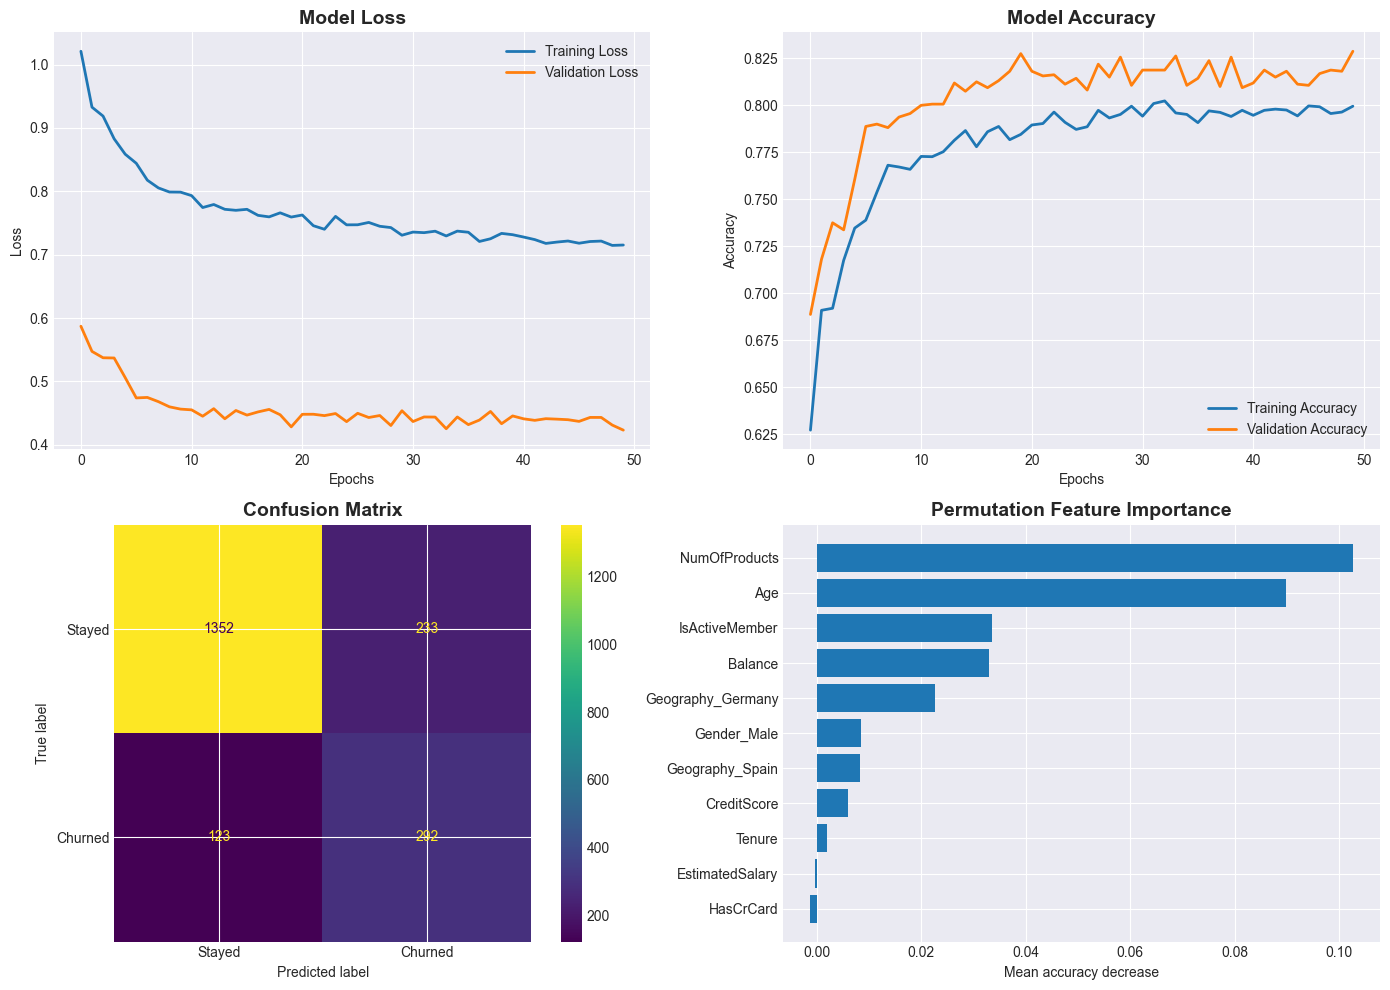

In [15]:
# ── Performance visualisations ───────────────────────────────────────────────
from sklearn.inspection import permutation_importance

plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loss
axes[0, 0].plot(history.history['loss'],     label='Training Loss',   linewidth=2)
axes[0, 0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0, 0].set_title('Model Loss',     fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epochs')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()

# 2. Accuracy
axes[0, 1].plot(history.history['accuracy'],     label='Training Accuracy',   linewidth=2)
axes[0, 1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0, 1].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epochs')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()

# 3. Confusion matrix
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Churned'])
disp.plot(ax=axes[1, 0], values_format='d')
axes[1, 0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')

# 4. Permutation importance (valid for neural networks)
# Wrap the Keras model in a sklearn-compatible class
from sklearn.base import BaseEstimator, ClassifierMixin

class KerasWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model): self.model = model
    def fit(self, X, y): return self
    def predict(self, X): return (self.model.predict(X, verbose=0) > 0.5).astype(int).flatten()
    def score(self, X, y): return accuracy_score(y, self.predict(X))

wrapped    = KerasWrapper(model)
perm_imp   = permutation_importance(wrapped, X_test_scaled, y_test,
                                    n_repeats=10, random_state=42)
feat_names = X_train.columns.tolist()
perm_df    = pd.DataFrame({'Feature': feat_names,
                            'Importance': perm_imp.importances_mean}).sort_values('Importance')

axes[1, 1].barh(perm_df['Feature'], perm_df['Importance'])
axes[1, 1].set_title('Permutation Feature Importance', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Mean accuracy decrease')

plt.tight_layout()
plt.show()

In [34]:
# ── Save model, scaler, and column list ──────────────────────────────────────
os.makedirs("../models", exist_ok=True)

# Save in .h5 format for cross-version compatibility with Streamlit Cloud
model.save('../models/churn_prediction_model.h5')

# Save scaler
joblib.dump(scaler, '../models/scaler.pkl')

# Save training column list (needed at inference time to align new inputs)
joblib.dump(training_columns, '../models/training_columns.pkl')

print("Model saved to  : ../models/churn_prediction_model.h5")
print("Scaler saved to : ../models/scaler.pkl")
print("Columns saved to: ../models/training_columns.pkl")

Model saved to  : ../models/churn_prediction_model.h5
Scaler saved to : ../models/scaler.pkl
Columns saved to: ../models/training_columns.pkl


## 🔮 Inference — Predicting Churn for New Customers

At inference time the same three assets are loaded:
1. `churn_prediction_model.keras` — the trained neural network
2. `scaler.pkl` — the fitted `StandardScaler`
3. `training_columns.pkl` — the exact column list produced after one-hot encoding

This guarantees that new customer data is encoded identically to how the training data was processed.

In [31]:
# ── Test customers ────────────────────────────────────────────────────────────
test_customers = [
    # HIGH RISK 🔴 — German, inactive, middle-aged, low credit
    {"CreditScore": 450,  "Geography": "Germany", "Gender": "Male",   "Age": 55,
     "Tenure": 1,  "Balance": 150000, "NumOfProducts": 2, "HasCrCard": 1,
     "IsActiveMember": 0, "EstimatedSalary": 50000},

    # MEDIUM RISK 🟡 — France, inactive, mid-age, average profile
    {"CreditScore": 650,  "Geography": "France",  "Gender": "Male",   "Age": 40,
     "Tenure": 4,  "Balance": 60000,  "NumOfProducts": 1, "HasCrCard": 1,
     "IsActiveMember": 0, "EstimatedSalary": 80000},
    
    # LOW RISK 🟢 — France, active, very young, excellent credit, zero balance
    {"CreditScore": 850,  "Geography": "France",  "Gender": "Female", "Age": 19,
     "Tenure": 9,  "Balance": 0,      "NumOfProducts": 1, "HasCrCard": 1,
     "IsActiveMember": 1, "EstimatedSalary": 200000},
]

probs = predict_customers(test_customers)

print("=" * 50)
print("PREDICTION RESULTS")
print("=" * 50)
for i, prob in enumerate(probs):
    risk = get_risk_tier(prob)
    print(f"Customer {i+1}: Churn Probability = {prob:.2%}  —  {risk} RISK")

PREDICTION RESULTS
Customer 1: Churn Probability = 87.10%  —  HIGH 🔴 RISK
Customer 2: Churn Probability = 41.80%  —  MEDIUM 🟡 RISK
Customer 3: Churn Probability = 27.65%  —  LOW 🟢 RISK


### 🏆 Final Model Selection

Several machine learning models were evaluated, including Logistic Regression, Decision Tree, and a Neural Network.

The **Neural Network model built using TensorFlow/Keras** was selected as the final model for this project because it significantly outperforms the baseline models and captures complex, non-linear patterns in customer behaviour that simpler models miss. Decision Trees tend to overfit, and Logistic Regression assumes linear relationships — both limitations the Neural Network overcomes with its layered architecture and Dropout regularisation.

This trained model is deployed in a **Streamlit application** to predict whether a customer is likely to churn based on their information.

## 🚀 Model Deployment

After evaluating the model, it was deployed using **Streamlit** to create an interactive web application that allows users to predict customer churn in real time.

---

### 🖥 Deployment Framework

The application provides an interactive interface where users can input customer information and receive churn predictions instantly using the trained Neural Network model.

---

### 📊 Application Features

The deployed dashboard includes:

- **Customer Input Panel** — credit score, age, tenure, balance, number of products, credit card status, active membership, estimated salary, geography, and gender
- **Real Model Inference** — predictions from the trained neural network via `churn_prediction_model.keras`
- **Three Risk Tiers** — High (>50%), Medium (30–50%), Low (<30%) with visual progress bar
- **Retention Suggestions** — contextual tips based on the customer's specific risk factors

---

### ⚙️ Running the Application
```bash
streamlit run app/app.py
```

The application loads `churn_prediction_model.keras`, `scaler.pkl`, and `training_columns.pkl` from the `../models/` directory.

## 🎯 Final Summary

### ✅ What We Accomplished

- Built a **Neural Network model** to predict customer churn
- Achieved **~80% test accuracy** (with class-balanced training)
- Performed **data preprocessing, feature scaling, and categorical encoding**
- Trained and evaluated multiple models (Logistic Regression, Decision Tree, Neural Network) and selected the best performer
- Addressed **80/20 class imbalance** using class weights across all models
- Used **permutation importance** to identify key churn indicators
- Identified key churn indicators such as **Geography, Age (50–60 at 56.2%), and Customer Activity**
- Developed an **interactive prediction dashboard using Streamlit** with real model inference

---

### 💡 Business Recommendations

1. **Target German customers** with special retention offers as they show higher churn probability.
2. **Engage inactive members** through loyalty programs, personalised emails, or incentives.
3. **Focus on customers aged 50–60**, as this group has the highest churn rate at 56.2%.
4. **Monitor customers aged 40–50** as they represent the second highest risk group at 34.0%.
5. Introduce **personalised financial products** based on customer behaviour and risk score.

---

### 🚀 Future Improvements

- Improve model performance using **Gradient Boosting or XGBoost**
- Perform **hyperparameter tuning** to further optimise prediction accuracy
- Incorporate **additional customer behaviour features** such as transaction frequency and service usage
- Implement **A/B testing strategies** to evaluate the effectiveness of churn reduction campaigns
- Build a **real-time data pipeline** for automated churn monitoring

---

### 📋 Project Information

**Created by:** Ayushi Rai  
**Project:** Customer Churn Prediction  
**Model:** Neural Network (TensorFlow / Keras)  
**Test Accuracy:** ~80%  
**Date:** March 2026

---